In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [37]:
df = sns.load_dataset('Iris')

In [38]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [39]:
df.species.unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [40]:
data = df[["sepal_length","petal_width","species"]]

In [41]:
data.sample(10)

,sepal_length,petal_width,species
105,7.6,2.1,virginica
114,5.8,2.4,virginica
115,6.4,2.3,virginica
59,5.2,1.4,versicolor
35,5.0,0.2,setosa
53,5.5,1.3,versicolor
79,5.7,1.0,versicolor
111,6.4,1.9,virginica
12,4.8,0.1,setosa
139,6.9,2.1,virginica


<Axes: xlabel='sepal_length', ylabel='Density'>

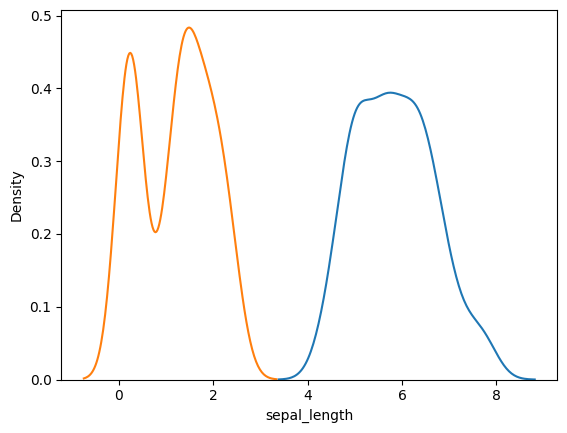

In [42]:
sns.kdeplot(df['sepal_length'])
sns.kdeplot(df['petal_width'])

In [43]:
X = data.drop(columns=["species"])
y = data["species"]

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [45]:
lr = LogisticRegression()

In [46]:
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
y_pred = lr.predict(X_test)

In [48]:
lr.intercept_

array([ 9.90095656, -0.28953178, -9.61142478])

In [49]:
lr.coef_

array([[-1.12290861, -3.49048311],
       [ 0.27681444, -0.00910375],
       [ 0.84609417,  3.49958686]])

In [50]:
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [51]:
accuracy_score(y_test,y_pred)

1.0

In [52]:
confusion_matrix(y_test,y_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



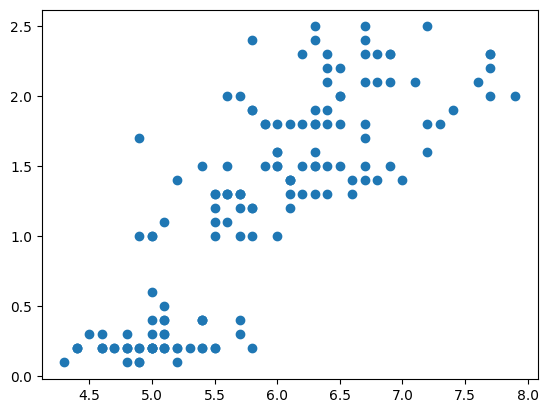

In [54]:
plt.scatter(data['sepal_length'],data['petal_width'])

In [74]:
from sklearn.preprocessing import LabelEncoder

In [75]:
le = LabelEncoder()

In [79]:
data['species'] = le.fit_transform(data['species'])
data

,sepal_length,petal_width,species
0,5.1,0.2,0
1,4.9,0.2,0
2,4.7,0.2,0
3,4.6,0.2,0
4,5.0,0.2,0
...,...,...,...
145,6.7,2.3,2
146,6.3,1.9,2
147,6.5,2.0,2
148,6.2,2.3,2


In [80]:
X_train.shape

(120, 2)

In [124]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

In [135]:
class LR: # gd
    def __init__(self,max_iter=100,lr=0.01):
        self.weights = None
        self.max_iter = max_iter
        self.lr = lr

    def sigmoid(self,x):
        return 1 / (1 + np.exp(-x))

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        self.weights  = np.ones(X_train.shape[1])

        for _ in range(self.max_iter):
            y_hat = self.sigmoid(np.dot(X_train,self.weights))
            
            gd = (np.dot((y_train - y_hat),X_train)) / X_train.shape[0]
            self.weights  += self.lr * gd 

        return self.weights[1:],self.weights[0]

    def predict_proba(self, X):

        X = np.insert(X, 0, 1, axis=1)

        return self.sigmoid(np.dot(X, self.weights))

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

In [136]:
model = LR(max_iter=2500,lr=0.5)

In [137]:
model.fit(X,y)

(array([4.36410145, 0.17189254]), np.float64(5.148029492159727))

In [138]:
model.predict(X)

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [144]:
model.predict_proba(X)

array([9.99363563e-01, 9.95023318e-01, 9.92161272e-01, 7.10517256e-05,
       9.97306208e-01, 2.81660679e-03, 5.02226120e-05, 9.99108740e-01,
       9.85229155e-01, 2.28434804e-05, 3.79567856e-05, 4.26613616e-05,
       9.97271866e-01, 9.99964022e-01, 4.09892919e-05, 9.99744917e-01,
       9.96883634e-01, 2.46589360e-05, 9.97150554e-01, 4.50283084e-05,
       5.64070846e-06, 1.48580953e-05, 3.37692612e-04, 9.99998782e-01,
       5.55914962e-04, 9.99925820e-01, 3.71305619e-05, 9.28852357e-04,
       2.67172440e-06, 4.27574273e-05, 2.02493348e-04, 9.99995311e-01,
       9.99504422e-01, 9.99861130e-01, 9.99842683e-01, 9.93042629e-01,
       1.62457717e-03, 9.99935696e-01, 1.01634630e-04, 9.99943226e-01,
       2.85516091e-04, 1.96070462e-03, 3.31789746e-04, 9.99997817e-01,
       3.02495003e-03, 9.99988613e-01, 9.99263095e-01, 2.26767941e-04,
       6.70274602e-04, 2.12075494e-03, 9.99368904e-01, 9.93312152e-01,
       2.23494527e-04, 9.99976532e-01, 9.99999868e-01, 1.33539138e-04,
      